In [29]:
import duckdb
import pandas as pd
import os
import json
from dotenv import load_dotenv

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

from catboost import CatBoostRegressor

sns.set_theme(style="whitegrid")


In [30]:
def extrair_features_moodle(pasta_dados="export/", curso_id="10464"):
    """
    Varre os logs brutos do Moodle e consolida métricas comportamentais 
    por aluno usando processamento analítico do DuckDB.
    """
    
    query_features = f"""
        SELECT 
            username,
            -- 1. Features de Volume de Engajamento
            COUNT(*) AS total_cliques,
            
            -- Converte o timestamp Unix para Data e conta os dias distintos estudados
            COUNT(DISTINCT CAST(to_timestamp(CAST(timecreated AS BIGINT)) AS DATE)) AS dias_ativos,
            
            -- 2. Features Comportamentais (Ativo vs Passivo)
            SUM(CASE WHEN crud IN ('c', 'u') THEN 1 ELSE 0 END) AS interacoes_ativas,
            SUM(CASE WHEN crud = 'r' THEN 1 ELSE 0 END) AS interacoes_passivas,
            
            -- 3. Features de Foco em Componentes
            SUM(CASE WHEN component = 'mod_forum' THEN 1 ELSE 0 END) AS cliques_forum,
            SUM(CASE WHEN component = 'mod_quiz' THEN 1 ELSE 0 END) AS cliques_quiz,
            SUM(CASE WHEN component IN ('mod_resource', 'mod_book', 'mod_page') THEN 1 ELSE 0 END) AS cliques_materiais
            
        FROM read_csv_auto('{pasta_dados}mdl_logstore_standard_log.csv', ALL_VARCHAR=TRUE)
        WHERE username NOT IN ('0', '-1', '', 'nan') 
          AND username IS NOT NULL
          AND courseid = '{curso_id}'
        GROUP BY username
        ORDER BY total_cliques DESC
    """
    
    # Executa a query e já devolve um DataFrame Pandas limpinho
    df_features = duckdb.query(query_features).df()
    return df_features

df = extrair_features_moodle()
print(df.head())

                  username  total_cliques  dias_ativos  interacoes_ativas  \
0  user6442803380426375169          31212           86             5250.0   
1  user8540069828419911681          24996           71            22080.0   
2  user7619359643386511361          17247           39             4721.0   
3  user7959886181284446209           7180           38              212.0   
4  user2959087468848087041           6685           36              679.0   

   interacoes_passivas  cliques_forum  cliques_quiz  cliques_materiais  
0              25806.0        18262.0         460.0             1376.0  
1               2892.0         1240.0          50.0              260.0  
2              12519.0        15427.0          33.0              182.0  
3               6965.0         5871.0         139.0              228.0  
4               6002.0         4658.0          37.0               77.0  


In [38]:
def extrair_notas_medias(pasta_dados="export/"):
    """
    Extrai a nota mais recente de cada item para cada aluno
    e calcula a nota média final (Target).
    """
    query_notas = f"""
        WITH NotasRecentes AS (
            -- Passo 1: Pegar apenas a nota mais recente (última modificação) de cada atividade por aluno
            SELECT 
                username,
                itemid,
                arg_max(CAST(finalgrade AS FLOAT), CAST(timemodified AS BIGINT)) as nota_recente
            FROM read_csv_auto('{pasta_dados}mdl_grade_grades_history.csv', ALL_VARCHAR=TRUE)
            WHERE finalgrade NOT IN ('', 'nan', 'None') AND finalgrade IS NOT NULL
              AND username NOT IN ('0', '-1', '', 'nan')
            GROUP BY username, itemid
        )
        -- Passo 2: Calcular a nota média por aluno a partir de suas notas mais recentes
        SELECT 
            username,
            AVG(nota_recente) AS nota_media
        FROM NotasRecentes
        GROUP BY username
        ORDER BY nota_media DESC
    """
    
    # Executa a query e retorna o DataFrame
    return duckdb.query(query_notas).df()

# Executa a função e guarda o DataFrame com o nosso "Target"
df_target = extrair_notas_medias()

# Exibe as primeiras linhas para validação
display(df_target.head())

,username,nota_media
0,user7232449863873462273,80.0
1,user8749729812320354305,80.0
2,user7863879879668793345,80.0
3,user968703755916673025,80.0
4,user2111797327378251777,80.0


In [ ]:
from functools import reduce

# 1. Configuração

load_dotenv()

export_path = os.getenv("PASTA_DADOS")

atividades_path = os.path.join(export_path, "atividades.json")
nivel_desordem_path = os.path.join(export_path, "nivel_desordem.json")
visualizacoes_por_objeto_path = os.path.join(export_path, "visualizacoes_por_objeto.json")
proporcao_visualizacoes_path = os.path.join(export_path, "proporcao_visualizacoes_por_atividade.json")
pontuacao_path = os.path.join(export_path, "pontuacao.json")
porcentagem_curso_path = os.path.join(export_path, "porcentagem_curso_acessada.json")
tentativas_por_questionario_path = os.path.join(export_path, "tentativas_por_questionario.json")
tempo_resposta_path = os.path.join(export_path, "tempo_resposta.json")
tempo_total_gasto_path = os.path.join(export_path, "tempo_total_gasto_em_visitas_reais.json")

# 2.1. Desordem por Sessão

with open(nivel_desordem_path, 'r', encoding='utf-8') as f:
    desordem_json = json.load(f)
dados_desordem = {}
for id_sessao, dados_sessao in desordem_json.get("Course 10464", {}).get("sessoes", {}).items():
    for username, valor in dados_sessao.get("nivel_desordem_por_usuario", {}).items():
        if username not in dados_desordem:
            dados_desordem[username] = {"username": username}
        dados_desordem[username][f"desordem_sessao_{id_sessao}"] = valor
df_desordem = pd.DataFrame(list(dados_desordem.values()))

# 2.2. Pontuação
with open(pontuacao_path, 'r', encoding='utf-8') as f:
    pont_data = json.load(f)
df_pontuacao = pd.DataFrame(pont_data)[['usuario', 'pontuacao']]
df_pontuacao = df_pontuacao.rename(columns={'usuario': 'username'}) # Padronizando a chave

# 2.3. Porcentagem do Curso Acessada (Desdobrando geral e sessões)
with open(porcentagem_curso_path, 'r', encoding='utf-8') as f:
    perc_json = json.load(f)
dados_perc = []
for username, dados_aluno in perc_json.get('Course 10464', {}).items():
    registro = {'username': username, 'porcentagem_geral': dados_aluno.get('geral', 0.0)}
    # Expande as sessões também
    for id_sessao, valor_sessao in dados_aluno.get('sessoes', {}).items():
        registro[f'porcentagem_sessao_{id_sessao}'] = valor_sessao
    dados_perc.append(registro)
df_porcentagem = pd.DataFrame(dados_perc)

# 2.4. Tentativas por Questionário (Somando tudo por aluno)
with open(tentativas_por_questionario_path, 'r', encoding='utf-8') as f:
    tentativas_data = json.load(f)
df_tentativas = pd.DataFrame(tentativas_data)
df_tentativas = df_tentativas.groupby('usuario')['total_tentativas'].sum().reset_index()
df_tentativas = df_tentativas.rename(columns={'usuario': 'username', 'total_tentativas': 'soma_tentativas_quizzes'})

# 2.5. Tempo de Resposta (Transformando PT...S em segundos)
with open(tempo_resposta_path, 'r', encoding='utf-8') as f:
    tempo_resp_data = json.load(f)
df_tempo_resp = pd.DataFrame(tempo_resp_data)

# Solução à prova de falhas usando Regex para extrair (Dias, Horas, Minutos, Segundos)
regex_tempo = r'P(?:(\d+)D)?T(?:(\d+)H)?(?:(\d+)M)?(?:(\d+)S)?'
extraido_resp = df_tempo_resp['tempo_resposta'].str.extract(regex_tempo).fillna(0).astype(int)

# D*86400 + H*3600 + M*60 + S
df_tempo_resp['tempo_resp_segundos'] = (
    extraido_resp[0] * 86400 + 
    extraido_resp[1] * 3600 + 
    extraido_resp[2] * 60 + 
    extraido_resp[3]
)

# Tirando a média de tempo de resposta por aluno
df_tempo_resp = df_tempo_resp.groupby('usuario')['tempo_resp_segundos'].mean().reset_index()
df_tempo_resp = df_tempo_resp.rename(columns={'usuario': 'username', 'tempo_resp_segundos': 'media_tempo_resposta_seg'})


# ==========================================
# 2.6. Tempo Total Gasto na Plataforma
# ==========================================
with open(tempo_total_gasto_path, 'r', encoding='utf-8') as f:
    tempo_gasto_data = json.load(f)
df_tempo_gasto = pd.DataFrame(tempo_gasto_data)

# Aplicando a mesma extração Regex (O Moodle pode gerar números enormes como PT436985S aqui)
extraido_gasto = df_tempo_gasto['tempo_passado'].str.extract(regex_tempo).fillna(0).astype(int)

# Calculando Segundos
df_tempo_gasto['tempo_passado_seg'] = (
    extraido_gasto[0] * 86400 + 
    extraido_gasto[1] * 3600 + 
    extraido_gasto[2] * 60 + 
    extraido_gasto[3]
)

# Somando todo o tempo das visitas do aluno
df_tempo_gasto = df_tempo_gasto.groupby('usuario')['tempo_passado_seg'].sum().reset_index()
df_tempo_gasto = df_tempo_gasto.rename(columns={'usuario': 'username', 'tempo_passado_seg': 'tempo_total_ambiente_seg'})


# ==========================================
# 3. O GRANDE MERGE (Unindo tudo pelo Username)
# ==========================================
# Colocamos todos os DataFrames em uma lista
dataframes_para_unir = [
    df_desordem, 
    df_pontuacao, 
    df_porcentagem, 
    df_tentativas, 
    df_tempo_resp, 
    df_tempo_gasto,
    df
]

# Usamos reduce para fazer o OUTER JOIN em todos eles de forma sequencial
df_final = reduce(lambda left, right: pd.merge(left, right, on='username', how='outer'), dataframes_para_unir)

# ==========================================
# 4. TRATAMENTO FINAL DE NULOS
# ==========================================


# Para garantir que não haja usernames nulos ou vazios
df_final = df_final[df_final['username'] != 0.0]

print(f"✅ Matriz de features construída com sucesso! Total de alunos: {len(df_final)}")
print(f"📊 Total de features (colunas) geradas: {len(df_final.columns)}")

# Exibe a super tabela
display(df_final.head())

df_final.to_csv(os.path.join(export_path, "matriz_comportamental.csv"), index=False)

✅ Matriz de features construída com sucesso! Total de alunos: 2168
📊 Total de features (colunas) geradas: 24


,username,desordem_sessao_58964,desordem_sessao_58966,desordem_sessao_58965,desordem_sessao_58968,desordem_sessao_58967,pontuacao,porcentagem_geral,porcentagem_sessao_58964,porcentagem_sessao_58966,...,soma_tentativas_quizzes,media_tempo_resposta_seg,tempo_total_ambiente_seg,total_cliques,dias_ativos,interacoes_ativas,interacoes_passivas,cliques_forum,cliques_quiz,cliques_materiais
0,user1002410981378228225,0.0000,0.0,0.0000,0.000,0.0000,0.00,5.56,0.0,18.18,...,0.0,0.000000,1797805,28,1,7.0,21.0,0.0,0.0,2.0
1,user1003176640903118849,0.0000,0.0,0.3138,0.000,0.0000,8.67,14.81,0.0,0.00,...,1.0,585.500000,4674426,75,4,20.0,55.0,0.0,7.0,24.0
2,user1011513786604978177,0.3869,0.0,0.7127,0.000,0.0000,9.50,38.89,100.0,54.55,...,4.0,1921.285714,1121166,211,2,59.0,152.0,18.0,26.0,61.0
3,user101338288765272065,0.0000,0.0,0.3869,0.000,0.0000,0.00,12.96,75.0,0.00,...,0.0,0.000000,940302,51,1,10.0,41.0,19.0,0.0,10.0
4,user1022941294420295681,0.3869,0.0,0.4106,0.865,0.5803,9.74,66.67,100.0,63.64,...,6.0,484.500000,831258,395,6,110.0,279.0,46.0,41.0,45.0


In [33]:
def aplicar_imputacao_simples(X, estrategia='median', valor_constante=0.0):
    """
    Aplica técnicas de imputação simples do Scikit-Learn para preencher valores nulos (NaN).
    Se a estratégia for 'nativo', retorna os dados intactos para o CatBoost processar nativamente.
    """
    if estrategia == 'nativo':
        # Não faz nada, deixa os NaNs para o CatBoost lidar sozinho
        return X.copy()
    
    print(f"Aplicando imputação: {estrategia}...")
    
    if estrategia == 'constant':
        imputer = SimpleImputer(strategy=estrategia, fill_value=valor_constante)
    else:
        imputer = SimpleImputer(strategy=estrategia)
    
    # Aplica a transformação e devolve como DataFrame do Pandas mantendo as colunas
    X_imputado = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)
    
    return X_imputado

In [34]:
def treinar_e_avaliar_catboost(X_train, X_test, y_train, y_test):
    """
    Treina o modelo CatBoostRegressor e extrai as métricas de erro da predição.
    """
    # O CatBoost não precisa de One-Hot Encoding ou escalonamento numérico.
    modelo = CatBoostRegressor(
        iterations=500,           # Quantidade máxima de árvores
        learning_rate=0.05,       # Passo de aprendizado
        depth=6,                  # Profundidade da árvore
        loss_function='RMSE',
        verbose=0,                # 0 para não poluir a tela com logs do treinamento
        random_seed=42            # Garante que o resultado seja reprodutível
    )
    
    # Treina o modelo
    modelo.fit(X_train, y_train)
    
    # Faz a predição nos dados de teste (que o modelo nunca viu)
    predicoes = modelo.predict(X_test)
    
    # Calcula as métricas de avaliação
    mae = mean_absolute_error(y_test, predicoes)
    rmse = root_mean_squared_error(y_test, predicoes)
    r2 = r2_score(y_test, predicoes)
    
    return modelo, mae, rmse, r2

🔄 Juntando a matriz de features com o Target...

🚀 Iniciando Treinamentos...
------------------------------
Aplicando imputação: mean...
Aplicando imputação: median...
Aplicando imputação: most_frequent...
Aplicando imputação: constant...

🏆 RANKING DE DESEMPENHO DAS ESTRATÉGIAS:


,Estrategia,MAE (Erro em % da nota),RMSE,R² (Poder Explicativo)
0,nativo,6.620391,10.634956,0.389535
2,median,6.692789,10.547386,0.399547
1,mean,6.771424,10.796235,0.370880
3,most_frequent,6.777890,10.865620,0.362767
4,constant,6.893079,10.959306,0.351731


C:\Users\Danilus04\AppData\Local\Temp\ipykernel_52816\758263724.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_resultados, x='Estrategia', y='MAE (Erro em % da nota)', palette='viridis')


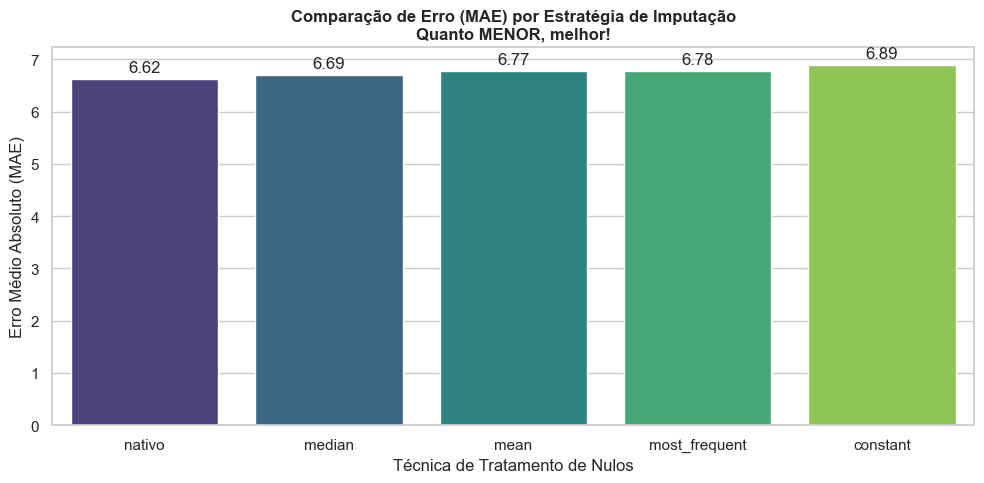

In [40]:
def executar_experimentos_imputacao(df_features, df_alvo, coluna_alvo='nota_media'):
    """
    Cruza as features com o Target, testa várias combinações de imputação
    e treina modelos CatBoost para descobrir qual abordagem gera o menor erro.
    """
    # 1. Cruzamento (Merge) usando INNER JOIN para manter apenas alunos com features E notas
    # NOTA: Certifique-se de que os seus DataFrames anteriores se chamam df_final e df_target_corrigido
    print("🔄 Juntando a matriz de features com o Target...")
    df_completo = pd.merge(df_features, df_alvo, on='username', how='inner')
    
    # 2. Separação de Variáveis (X = Comportamento, y = Nota Real)
    X = df_completo.drop(columns=['username', coluna_alvo])
    y = df_completo[coluna_alvo]
    
    # Se na criação da matriz de features você colocou ".fillna(0)", é importante 
    # recolocar como NaN aqui apenas para o experimento, simulando dados ausentes:
    X = X.replace(0.0, np.nan) 
    
    # 3. Lista de estratégias para testar
    estrategias = ['nativo', 'mean', 'median', 'most_frequent', 'constant']
    resultados = []
    
    print("\n🚀 Iniciando Treinamentos...\n" + "-"*30)
    
    for est in estrategias:
        # A) Imputação
        X_tratado = aplicar_imputacao_simples(X, estrategia=est, valor_constante=0.0)
        
        # B) Divisão em Treino (80%) e Teste (20%)
        X_train, X_test, y_train, y_test = train_test_split(X_tratado, y, test_size=0.2, random_state=42)
        
        # C) Treinamento e Avaliação
        modelo, mae, rmse, r2 = treinar_e_avaliar_catboost(X_train, X_test, y_train, y_test)
        
        # Guarda o resultado
        resultados.append({
            'Estrategia': est,
            'MAE (Erro em % da nota)': mae,
            'RMSE': rmse,
            'R² (Poder Explicativo)': r2
        })
        
    # 4. Exibição dos Resultados Finais
    df_resultados = pd.DataFrame(resultados).sort_values(by='MAE (Erro em % da nota)', ascending=True)
    
    print("\n🏆 RANKING DE DESEMPENHO DAS ESTRATÉGIAS:")
    display(df_resultados)
    
    # Bônus: Plota um gráfico comparativo
    plt.figure(figsize=(10, 5))
    ax = sns.barplot(data=df_resultados, x='Estrategia', y='MAE (Erro em % da nota)', palette='viridis')
    plt.title('Comparação de Erro (MAE) por Estratégia de Imputação\nQuanto MENOR, melhor!', fontweight='bold')
    plt.ylabel('Erro Médio Absoluto (MAE)')
    plt.xlabel('Técnica de Tratamento de Nulos')
    
    # Adiciona os valores nas barras
    for i in ax.containers:
        ax.bar_label(i, fmt='%.2f', label_type='edge', padding=3)
        
    plt.tight_layout()
    plt.show()

# =========================================================
# GATILHO DE EXECUÇÃO:
# Supondo que as tabelas extraídas nas respostas passadas
# estão nas variáveis df_final (features) e df_target_corrigido (alvo)
# =========================================================
executar_experimentos_imputacao(df_final, df_target, coluna_alvo='nota_media')